In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
import os

START = os.getenv['START', '2025-01-01']
END = os.getenv['END', '2025-01-30']

import uuid

short_uuid = uuid.uuid4().hex[:6]

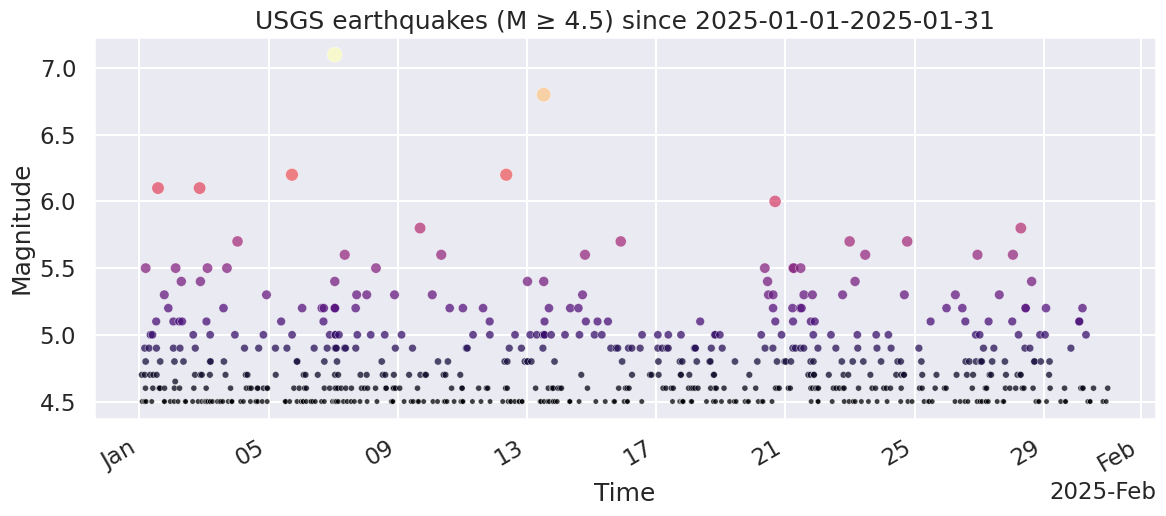

In [5]:
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {"format": "csv", "starttime": START, "endtime": END, "minmagnitude": 4.5}
df = pd.read_csv(url + "?" + "&".join(f"{k}={v}" for k, v in params.items()),
                 parse_dates=["time"])

df = df.sort_values("time")

sns.set_theme(style="darkgrid", context="talk", palette="deep")
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.scatterplot(
    data=df,
    x="time",
    y="mag",
    hue="mag",
    palette="magma",
    size="mag",
    sizes=(15, 120),
    alpha=0.75,
    edgecolor="white",
    linewidth=0.35,
    legend=False,
    ax=ax,
)
ax.set_xlabel("Time")
ax.set_ylabel("Magnitude")
ax.set_title(f"USGS earthquakes (M ≥ 4.5) since {starttime}-{endtime}")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate()
plt.tight_layout()

img_name = f"plot-{START}--{END}-{short_uuid}.png"
fig.savefig(img_name, dpi=150) #save file outside of the notebook
#plt.show()

In [ ]:
#cell for uplaods

%pip install boto3

import boto3
from botocore.exceptions import ClientError
#import os

s3 - boto.client('s3', region_name = 'us-east-1')
bucket = "uvasds-data"
UVAID = "vxx4kn"
key = "ds5229_1/" + UVAID + "/" + img_name  #path to file not just file name

try:
    s3.upload_file(img_name, bucket, key)
    print("Upload Successful")
except ClientError as e:
    print(e)